# Unidad 1 · Redes neuronales para la prospectividad aurífera

Adaptación de **Reto_Aguacates_Capitulo8_U1_U2_U3_EXHAUSTIVO_Solucion**, exclusivamente apartados **1.1–1.7**, y del contexto `implementar Unidad 1.txt`. Consulta [la guía](LEEME_UNIDAD1.md).

El reto aporta los fundamentos y la necesidad de comparar con referencias sencillas. El TXT aporta la MLP `32 → 16 → 1`, ReLU, sigmoid, Adam y escalado. Su ejemplo genérico se adapta al protocolo espacial de GeoAI.

**Objetivo:** entender qué aprende una red y observar si ofrece una mejora exploratoria frente a RF y logística. Usamos datos reales de GeoAI. `P=1` son candidatos en el modo diagnóstico vigente; `U=0` es fondo sin etiqueta, no ausencia confirmada. Un score sigmoid no es la probabilidad absoluta de encontrar oro.

**Límite:** solo validaciones internas del fold externo predefinido `outer_00`. El test externo y la reserva permanecen cerrados. No se desarrollan la Unidad 2 ni la 3; Keras se usa como herramienta, igual que en U1 del reto.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from scipy.special import expit, softmax

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/geoau/neural_u1.py').is_file())
if str(ROOT/'src') not in sys.path: sys.path.insert(0, str(ROOT/'src'))
from geoau import neural_u1 as u1
from geoau import evaluation as ev
cfg = u1.read_config(ROOT)
tf = u1.tensorflow()
tf.keras.utils.set_random_seed(cfg['seed'])
tf.config.experimental.enable_op_determinism()
print('Python:', sys.version.split()[0], '| TensorFlow:', tf.__version__)
display(cfg)

Python: 3.13.15 | TensorFlow: 2.21.0


{'schema_version': 1,
 'phase_f_run': 'reports/fase_f/20260909T184735_016759Z',
 'output_directory': 'reports/unidad1',
 'seed': 42,
 'outer_split': 'outer_00',
 'ratio_u_to_p': 3,
 'repetition': 0,
 'epochs': 100,
 'batch_size': 32,
 'patience': 10,
 'learning_rate': 0.001,
 'minimum_relevant_gain': 0.02,
 'architectures': [{'name': 'mlp_superficial',
   'hidden': [32],
   'dropout': 0.0,
   'l2': 0.0},
  {'name': 'mlp_u1', 'hidden': [32, 16], 'dropout': 0.0, 'l2': 0.0},
  {'name': 'mlp_profunda', 'hidden': [64, 32, 16], 'dropout': 0.0, 'l2': 0.0},
  {'name': 'mlp_regularizada',
   'hidden': [32, 16],
   'dropout': 0.2,
   'l2': 0.001}]}

## Preparación · datos, particiones y escalado

Reutilizamos las muestras P/U de E, la lista de predictores autorizada para diagnóstico por D y los marcos de evaluación de F. Las claves, coordenadas, etiquetas y pesos quedan fuera de X. Imputación con mediana y `StandardScaler` se ajustan **solo en train interno**. Las categorías geológicas se codifican con one-hot aprendido en train, con estados ausente/desconocido.

La validación conserva todas sus celdas para recuperación territorial y una muestra P/U fija para BCE, AP, AUC y F1. La BCE de validación depende de esa mezcla P/U y no acredita calibración física. Los folds internos se solapan en sus entrenamientos: su dispersión no es un intervalo de confianza.

In [2]:
fcfg, SOURCE, X, schema, partitions = u1.load_context(ROOT, cfg)
display(pd.DataFrame([{'split': s, 'train_P': int(sample.sample_class.sum()),
                      'train_U': int(sample.sample_class.eq(0).sum()),
                      'validation_cells': len(frame), 'validation_PU': int(frame.pu_metric_member.sum())}
                     for s, (sample, frame, _) in partitions.items()]))
split = next(iter(partitions))
sample, frame, _ = partitions[split]
print('Modo:', fcfg['mode'], '| Predictores originales:', len(schema['columns']))
# Dos variables continuas reales para la geometría; no son un modelo final.
cols2 = ['dist_falla_cartografiada_m', 'pendiente_grados']
pre2 = u1.make_preprocessor(cols2, [])
train2 = pre2.fit_transform(X.loc[sample.cell_id, cols2])
mask = frame.pu_metric_member.to_numpy(dtype=bool)
val2 = pre2.transform(X.loc[frame.loc[mask, 'cell_id'], cols2])
ytrain = sample.sample_class.to_numpy()
yval = frame.loc[mask, 'observed_P'].to_numpy(dtype=int)
display(pd.DataFrame({'variable': cols2,
    'mediana_train': pre2.named_steps['preprocess'].named_transformers_['numeric'].named_steps['impute'].statistics_,
    'media_tras_imputar_train': pre2.named_steps['preprocess'].named_transformers_['numeric'].named_steps['scale'].mean_}))

,split,train_P,train_U,validation_cells,validation_PU
0,outer_00_inner_00,277,831,97931,10088
1,outer_00_inner_01,178,534,91214,10163
2,outer_00_inner_02,219,657,97744,10127


Modo: diagnostic | Predictores originales: 93


,variable,mediana_train,media_tras_imputar_train
0,dist_falla_cartografiada_m,946.338440,1626.109211
1,pendiente_grados,3.030686,4.421703


In [3]:
ytrain

array([1, 1, 1, ..., 0, 0, 0], shape=(1108,))

## 1.1 · Perceptrón

Una neurona calcula $z=x^T w+b$ y decide mediante $\hat y=1[z\geq0]$. Los pesos cambian la orientación de la frontera y el sesgo la desplaza. No son efectos causales geológicos.

Primero comprobamos OR y AND; después ajustamos una frontera con **distancia a falla cartografiada y pendiente**. Esta proyección 2D pierde información: su limitación no demuestra por sí sola la necesidad de una red profunda.

In [5]:
logic = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)
display(pd.DataFrame({'x1': logic[:,0], 'x2': logic[:,1],
    'OR': u1.perceptron_predict(logic, [1,1], -.5),
    'AND': u1.perceptron_predict(logic, [1,1], -1.5)}))
perc = Perceptron(random_state=cfg['seed'], max_iter=2000, tol=1e-4).fit(train2, ytrain)
print('Accuracy train:', accuracy_score(ytrain, perc.predict(train2)))
print('Accuracy validation P/U:', accuracy_score(yval, perc.predict(val2)))
print('Baseline mayoritaria validation:', max(yval.mean(), 1-yval.mean()))
print('Pesos:', perc.coef_, 'bias:', perc.intercept_)

,x1,x2,OR,AND
0,0.0,0.0,0,0
1,0.0,1.0,1,0
2,1.0,0.0,1,0
3,1.0,1.0,1,1


Accuracy train: 0.6570397111913358
Accuracy validation P/U: 0.7043021411578113
Baseline mayoritaria validation: 0.9912767644726408
Pesos: [[0.01946105 0.6415371 ]] bias: [0.]


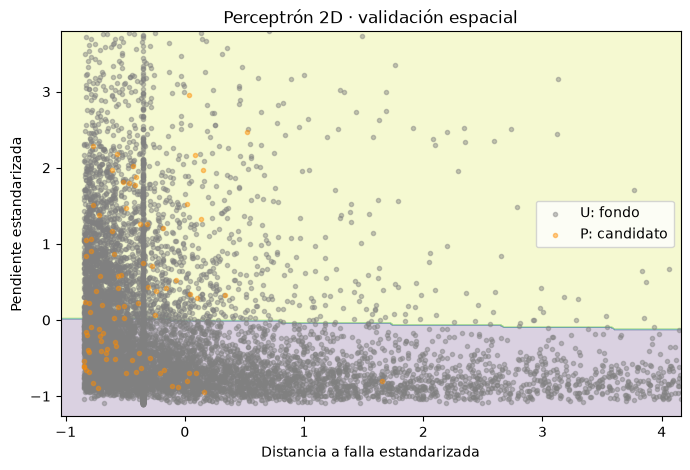

In [6]:
# Cuantiles solo para encuadrar la figura; no cambian entrenamiento ni métricas.
lo, hi = np.quantile(val2, [.01, .99], axis=0)
xx, yy = np.meshgrid(np.linspace(lo[0]-.2, hi[0]+.2, 180), np.linspace(lo[1]-.2, hi[1]+.2, 180))
zz = perc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(8,5))
ax.contourf(xx, yy, zz, alpha=.2)
for label, color, name in [(0,'gray','U: fondo'), (1,'darkorange','P: candidato')]:
    points = val2[yval == label]
    ax.scatter(points[:,0], points[:,1], s=9, alpha=.45, color=color, label=name)
ax.set(xlim=(lo[0]-.2,hi[0]+.2), ylim=(lo[1]-.2,hi[1]+.2),
       xlabel='Distancia a falla estandarizada', ylabel='Pendiente estandarizada',
       title='Perceptrón 2D · validación espacial')
ax.legend(); plt.show()

## 1.2 · MLP y XOR

XOR vale 1 cuando una sola entrada vale 1. Ninguna recta separa las dos diagonales. Una capa oculta crea otra representación: podemos calcular OR y AND y combinar sus salidas. Estos cuatro puntos son una demostración lógica, no datos geológicos simulados que sustituyan al proyecto.

Entrenamos también una MLP pequeña de Keras para observar el mismo mecanismo.

In [7]:
yxor = np.array([0,1,1,0], dtype=np.float32)
display(pd.DataFrame({'x1': logic[:,0], 'x2': logic[:,1], 'XOR_manual': u1.xor_manual(logic)}))
tf.keras.utils.set_random_seed(cfg['seed'])
xor_model = tf.keras.Sequential([tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation='tanh'), tf.keras.layers.Dense(1, activation='sigmoid')])
xor_model.compile(optimizer=tf.keras.optimizers.Adam(.03), loss='binary_crossentropy')
# Un único lote, repetido; evita crear un iterador de datos por cada una de 600 épocas.
for epoch in range(600):
    xor_model.train_on_batch(logic.astype(np.float32), yxor)
xor_scores = xor_model(logic.astype(np.float32), training=False).numpy().ravel()
display(pd.DataFrame({'objetivo': yxor, 'score': xor_scores, 'prediccion': xor_scores >= .5}))
assert np.array_equal(xor_scores >= .5, yxor.astype(bool)), 'Esta ejecución no resolvió XOR.' 

,x1,x2,XOR_manual
0,0.0,0.0,0
1,0.0,1.0,1
2,1.0,0.0,1
3,1.0,1.0,0


,objetivo,score,prediccion
0,0.0,0.000173,False
1,1.0,0.996447,True
2,1.0,0.998423,True
3,0.0,0.003406,False


## 1.3 · Propagación hacia delante

Para una celda real de **train**, calculamos $z_1=xW_1+b_1$, $h_1=ReLU(z_1)$, $z_2=h_1W_2+b_2$ y $s=\sigma(z_2)$. Los pesos de este ejemplo son didácticos y no están entrenados; el número final no mide prospectividad validada.

Una red profunda repite composiciones de esta forma. Sin activaciones no lineales, apilar transformaciones afines equivale a otra transformación afín.

In [10]:
forward = u1.forward_manual(train2[0])
for name, value in forward.items(): print(name, '=', value)

x = [-0.52580732  0.44592797]
z1 = [-0.45442425  0.41165811 -0.12371807]
h1 = [0.         0.41165811 0.        ]
z2 = -0.18582905259397292
score_PU = 0.45367596700282026


## 1.4 · Error, backpropagation y descenso de gradiente

Adaptamos el descenso sobre precio del reto al objetivo binario P/U de GeoAI. La entropía cruzada binaria es $L=-\frac1n\sum_i[y_i\log s_i+(1-y_i)\log(1-s_i)]$.

Para una neurona sigmoid, $\partial L/\partial z=(s-y)/n$. Así, $\nabla_w L=X^T(s-y)/n$ y $\partial L/\partial b=mean(s-y)$. Actualizamos $\theta\leftarrow\theta-\eta\nabla L$.

En una MLP, la regla de la cadena lleva el error a las capas ocultas: $\delta_1=(\delta_2 W_2^T)\odot 1[z_1>0]$ para ReLU, y $\nabla_{W_1}L=X^T\delta_1$. Keras calcula estas derivadas durante el entrenamiento; aquí verificamos manualmente todos los parámetros de una neurona con diferencias finitas.

,analytic,finite_difference,absolute_error
0,0.146219,0.146219,1.436157e-12
1,-0.294142,-0.294142,1.325934e-11
2,-0.522959,-0.522959,6.421486e-11


Pesos y bias finales: [-0.15203857  0.3115943  -0.97650988]
BCE inicial: 0.6931471805599453 | BCE tras actualizar: 0.5454465119699666


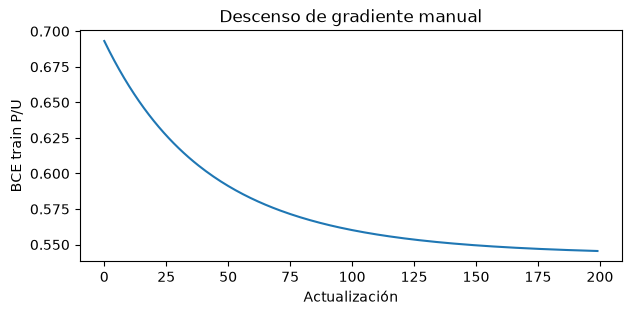

In [7]:
check = u1.gradient_check(np.array([.4, -.2, .1]), train2[:32], ytrain[:32])
display(check)
assert check.absolute_error.max() < 1e-6
theta, losses = u1.gradient_descent(train2, ytrain)
print('Pesos y bias finales:', theta)
print('BCE inicial:', losses[0], '| BCE tras actualizar:', u1.logistic_loss_gradient(theta, train2, ytrain)[0])
fig, ax = plt.subplots(figsize=(7,3))
ax.plot(losses); ax.set(xlabel='Actualización', ylabel='BCE train P/U', title='Descenso de gradiente manual')
plt.show()

## 1.5 · Funciones de activación

Step permite decidir, pero su derivada no sirve para entrenar por gradiente. Sigmoid produce una salida binaria en [0,1]; tanh centra su salida; ReLU introduce no linealidad; LeakyReLU conserva una pequeña pendiente negativa; linear sirve para regresión. Softmax normaliza un vector de logits para categorías mutuamente excluyentes.

GeoAI usa sigmoid con BCE para el contraste P/U. No inventamos clases BAJO/MEDIO/ALTO de oro a partir de cortes arbitrarios.

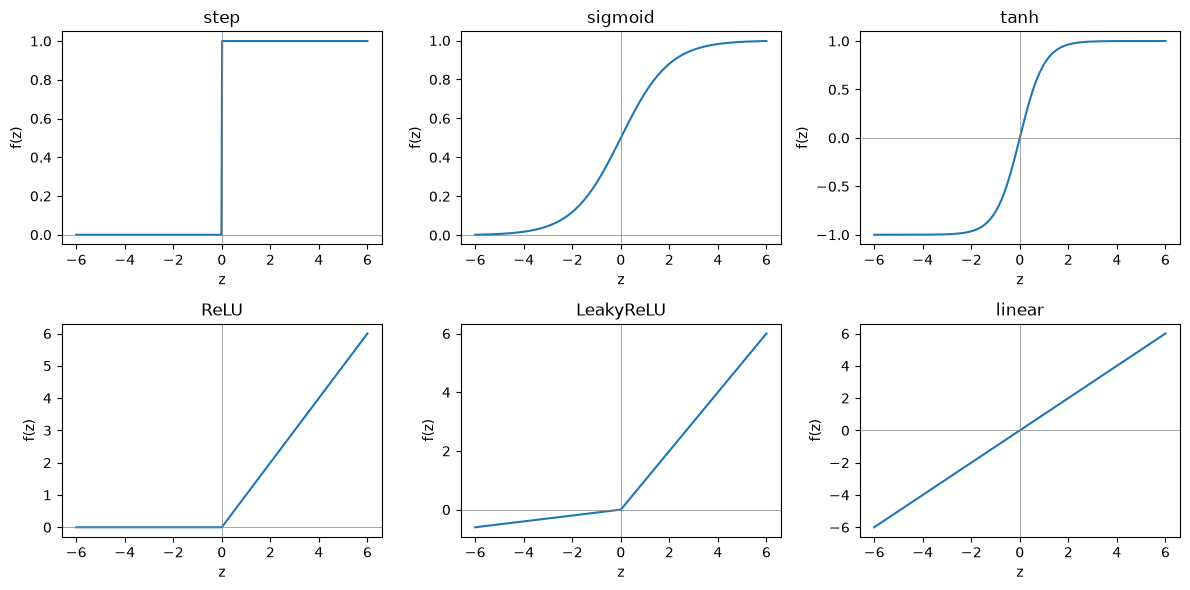

Softmax ilustrativa: [0.09003057 0.24472847 0.66524096] | suma: 0.9999999999999999


In [8]:
z = np.linspace(-6,6,400)
fig, axes = plt.subplots(2,3,figsize=(12,6))
for ax, (name, values) in zip(axes.flat, u1.activations(z).items()):
    ax.plot(z, values); ax.axhline(0,color='gray',lw=.5); ax.axvline(0,color='gray',lw=.5)
    ax.set(title=name, xlabel='z', ylabel='f(z)')
fig.tight_layout(); plt.show()
print('Softmax ilustrativa:', softmax([1.,2.,3.]), '| suma:', softmax([1.,2.,3.]).sum())

## 1.6 · Redes superficiales frente a profundas

Comparamos cuatro arquitecturas fijadas antes de ver las métricas: `[32]`, `[32,16]` (TXT), `[64,32,16]` y `[32,16]` con L2/Dropout. Adam usa `learning_rate=0.001`, hasta 100 épocas y lotes de 32. Cada MLP tiene salida sigmoid y BCE.

Las referencias son un perceptrón con todos los predictores, logística `C=1` y RF de 500 árboles con hoja mínima 5. Todos ven exactamente las mismas muestras y validaciones. RF y logística son referencias fijas reajustadas para este ensayo, no sus resultados externos históricos.

La recuperación al priorizar el 5 % del área es la métrica principal del proyecto. AP y ROC-AUC son métricas auxiliares P/U. F1 y accuracy usan umbral fijo 0.5 y no seleccionan arquitecturas. En el perceptrón, sigmoid transforma su margen para guardar scores; no lo calibra.

Se guardan configuración, versiones, hashes, preprocesadores, modelos `.keras`, curvas y predicciones de validación. Una ejecución completa y compatible se reutiliza.

In [9]:
try:
    RUN = u1.completed_run(ROOT)
except (FileNotFoundError, ValueError):
    RUN = u1.run_experiment(ROOT)
print('Resultados:', RUN)
results = pd.read_csv(RUN/'validation_metrics.csv')
display(results[['split_id','model','recovery_at_05','average_precision_PU','roc_auc_PU','f1_PU_at_05','parameters','best_epoch']])
display(results.groupby('model')[['recovery_at_05','average_precision_PU','roc_auc_PU','f1_PU_at_05']].agg(['mean','std']))

outer_00_inner_00 logistic: recovery@5%=0.2159


outer_00_inner_00 random_forest: recovery@5%=0.4318


outer_00_inner_00 perceptron: recovery@5%=0.3068


outer_00_inner_00 mlp_superficial: recovery@5%=0.2727


outer_00_inner_00 mlp_u1: recovery@5%=0.2727


...

outer_00_inner_02 mlp_profunda: recovery@5%=0.4094


outer_00_inner_02 mlp_regularizada: recovery@5%=0.4016


Resultados: C:\Users\Lenovo\Desktop\PROYECTO IA\GeoAI\GeoAI\reports\unidad1\20260920T112741_562792Z


,split_id,model,recovery_at_05,average_precision_PU,roc_auc_PU,f1_PU_at_05,parameters,best_epoch
0,outer_00_inner_00,logistic,0.215909,0.024979,0.748310,0.055500,NaN,NaN
1,outer_00_inner_00,random_forest,0.431818,0.219094,0.913075,0.304569,NaN,NaN
2,outer_00_inner_00,perceptron,0.306818,0.041115,0.809452,0.094714,NaN,NaN
3,outer_00_inner_00,mlp_superficial,0.272727,0.033935,0.828544,0.075171,5537.0,12.0
4,outer_00_inner_00,mlp_u1,0.272727,0.039814,0.822915,0.080134,6049.0,8.0
5,outer_00_inner_00,mlp_profunda,0.329545,0.040074,0.823315,0.095726,13633.0,3.0
6,outer_00_inner_00,mlp_regularizada,0.340909,0.047759,0.853750,0.086957,6049.0,10.0
7,outer_00_inner_01,logistic,0.404908,0.091166,0.865722,0.160311,NaN,NaN
8,outer_00_inner_01,random_forest,0.503067,0.184088,0.928833,0.239859,NaN,NaN
9,outer_00_inner_01,perceptron,0.257669,0.059319,0.779964,0.099000,NaN,NaN


recovery_at_05           average_precision_PU            \
                           mean       std                 mean       std   
model                                                                      
logistic               0.311926  0.094536             0.058966  0.033130   
mlp_profunda           0.395616  0.060355             0.081019  0.035646   
mlp_regularizada       0.435634  0.115581             0.094147  0.040244   
mlp_superficial        0.386322  0.106788             0.081665  0.041606   
mlp_u1                 0.383149  0.143992             0.070406  0.044113   
perceptron             0.264278  0.039651             0.051219  0.009266   
random_forest          0.471734  0.036392             0.191173  0.025139   

                 roc_auc_PU           f1_PU_at_05            
                       mean       std        mean       std  
model                                                        
logistic           0.822020  0.064201    0.109330  0.052463  
mlp_profunda       0.845062  0.051080    0.141558  0.046532  
mlp_regularizada   0.867031  0.041261    0.134372  0.051543  
mlp_superficial    0.857332  0.044581    0.119607  0.049413  
mlp_u1             0.836592  0.064592    0.132632  0.054847  
perceptron         0.810187  0.030597    0.096230  0.002403  
random_forest      0.891679  0.051314    0.244623  0.057711

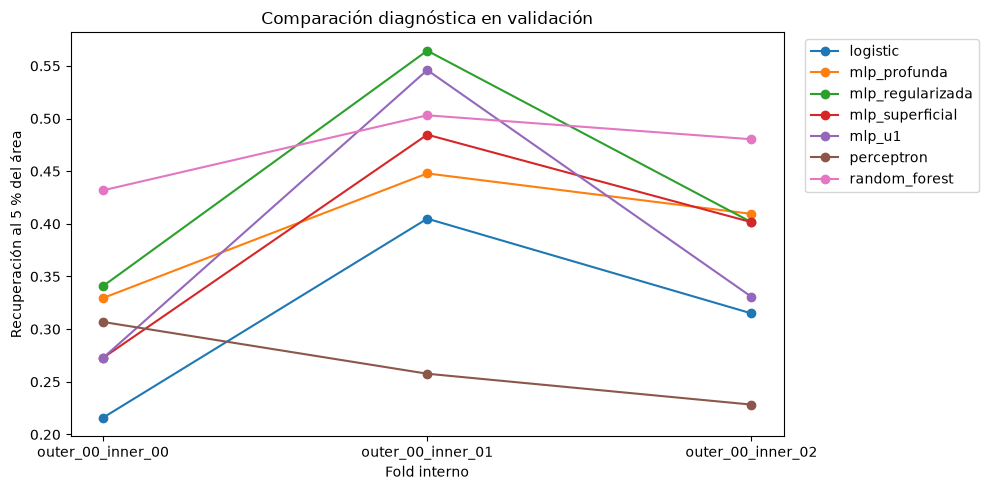

{'selected_by_validation': 'mlp_regularizada',
 'minimum_relevant_gain': 0.02,
 'mean_paired_gain': {'random_forest': -0.03609985171262405,
  'logistic': 0.1237077918941114},
 'promising_in_validation': False,
 'improvement_demonstrated_on_test': False,
 'interpretation': 'Selección exploratoria sobre folds internos dependientes; requiere evaluación final independiente para demostrar mejora.'}

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
for name, group in results.groupby('model'):
    ax.plot(group.split_id, group.recovery_at_05, marker='o', label=name)
ax.set(xlabel='Fold interno', ylabel='Recuperación al 5 % del área', title='Comparación diagnóstica en validación')
ax.legend(bbox_to_anchor=(1.02,1)); fig.tight_layout(); plt.show()
display(ev.read_json(RUN/'decision.json'))

## 1.7 · Problemas y soluciones

**Desvanecimiento del gradiente:** sigmoid saturada tiene una derivada cercana a cero. La multiplicación de muchas derivadas pequeñas debilita la señal hacia capas anteriores. ReLU ayuda, aunque neuronas siempre negativas también pueden quedar inactivas.

**Sobreajuste:** una caída de loss train acompañada de empeoramiento en validation sugiere memorización. L2 penaliza pesos grandes, Dropout desactiva unidades durante el entrenamiento y EarlyStopping restaura los pesos con menor `val_loss` (paciencia 10). Aquí la validación es un bloque espacial explícito, nunca un `validation_split` aleatorio.

La loss de modelos con L2 incluye penalización y Dropout actúa solo durante entrenamiento: una diferencia entre curvas no permite atribuir todo el efecto al sobreajuste. Tampoco debe compararse su valor absoluto como si las loss regularizadas y no regularizadas fueran idénticas.

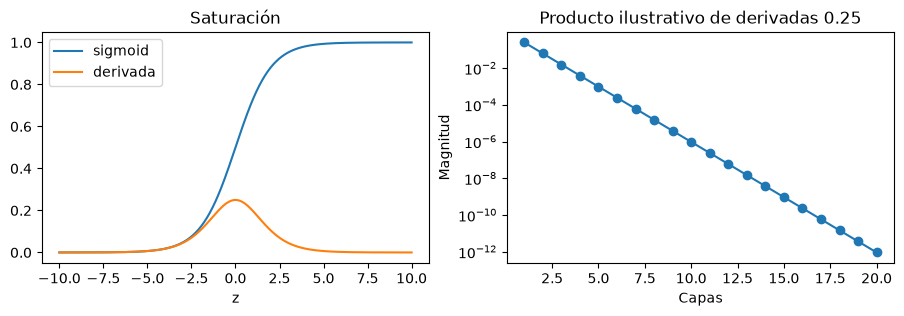

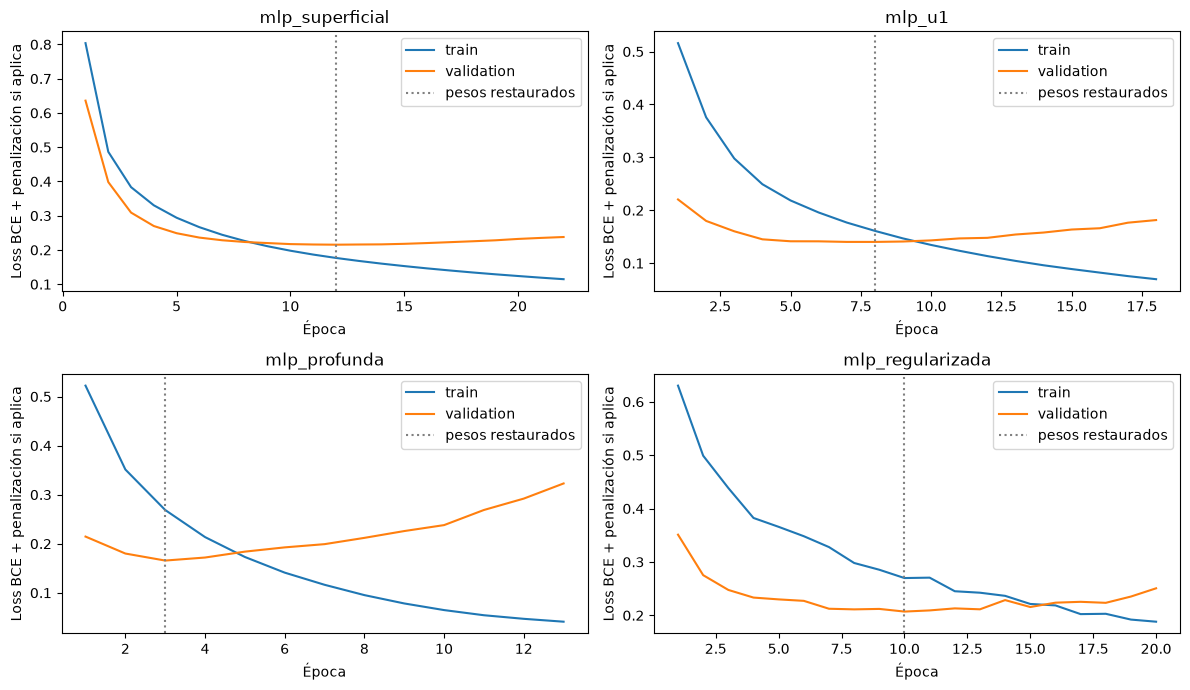

In [11]:
z = np.linspace(-10,10,500)
sig = expit(z)
fig, axes = plt.subplots(1,2,figsize=(11,3))
axes[0].plot(z,sig,label='sigmoid'); axes[0].plot(z,sig*(1-sig),label='derivada')
axes[0].legend(); axes[0].set(title='Saturación',xlabel='z')
depth = np.arange(1,21)
axes[1].semilogy(depth,.25**depth,marker='o')
axes[1].set(title='Producto ilustrativo de derivadas 0.25',xlabel='Capas',ylabel='Magnitud')
plt.show()
fig, axes = plt.subplots(2,2,figsize=(12,7))
for ax, arch in zip(axes.flat, cfg['architectures']):
    history = pd.read_csv(RUN/f"histories/{arch['name']}_{split}.csv")
    ax.plot(history.epoch,history.loss,label='train')
    ax.plot(history.epoch,history.val_loss,label='validation')
    best = history.loc[history.val_loss.idxmin(), 'epoch']
    ax.axvline(best,color='gray',linestyle=':',label='pesos restaurados')
    ax.set(title=arch['name'],xlabel='Época',ylabel='Loss BCE + penalización si aplica'); ax.legend()
fig.tight_layout(); plt.show()

## Cierre de Unidad 1

El archivo `decision.json` identifica la mejor arquitectura por media de recuperación en validación y cuantifica diferencias pareadas frente a RF y logística. El margen exploratorio predefinido es de 0.02 (dos puntos porcentuales de recuperación). Aunque lo supere, **no demuestra todavía una mejora en test**, porque la arquitectura y las épocas se han escogido con estas mismas validaciones.

Debes poder explicar qué hacen pesos y bias, por qué XOR necesita una representación no lineal, cómo se propaga una entrada y cómo el gradiente actualiza pesos. También, por qué la escala importa, qué activación corresponde a cada salida y por qué mayor profundidad puede empeorar la generalización.

**Preguntas para razonar:** ¿puede una accuracy alta deberse al predominio de U? ¿Qué cambia al aumentar profundidad si la recuperación territorial disminuye? ¿Por qué un score alto para una celda U no es necesariamente un falso positivo geológico?

**Fin de U1 (1.1–1.7).** El test externo y la reserva no reciben predicciones ni métricas en esta entrega.

In [12]:
display(ev.read_json(RUN/'control.json'))
ev.verify(RUN, ev.read_json(RUN/'outputs_manifest.json'))
assert not ev.read_json(RUN/'control.json')['test_evaluated']
assert not ev.read_json(RUN/'control.json')['holdout_evaluated']
print('Unidad 1 completada; artefactos verificados.')

{'status': 'completed',
 'scope': 'U1.1-U1.7',
 'mode': 'diagnostic',
 'test_evaluated': False,
 'holdout_evaluated': False,
 'production_allowed': False,
 'is_absolute_gold_probability': False}

Unidad 1 completada; artefactos verificados.
